# Lecture 3 — Robust Covariance Estimation
## Estimating and predicting the covariance matrix

This companion notebook reworks the old PyPortfolioOpt covariance walk-through using the
GAA framework's `risk_models/` package. It illustrates:

1. The sample covariance matrix and its correlation structure
2. How different estimators predict *future* variance (sample, shrinkage, EWMA, semicovariance)
3. A **factor model** for covariance, added to the same prediction comparison
4. Rolling correlations and a cross-estimator correlation-matrix comparison
5. Out-of-sample evaluation of the factor model (Frobenius loss, min-variance vol ratio)

Data: monthly indexed performance from `perf_M.parquet`
(generated by `data/run_pipes.py`). Columns ending in `-r` are simple monthly returns.

Code: `risk_models.covariance`, `risk_models.factor_covariance`, `risk_models.risk_analytics`,
`risk_models.utils` — see `risk_models/examples/covariance_example.py` and
`risk_models/examples/factor_covariance_example.py` for the full reports this notebook distils.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from risk_models.covariance import CovMethod, compute_covariance, compute_rolling_covariance
from risk_models.factor_covariance import compute_rolling_asset_factor_cov
from risk_models.risk_analytics import evaluate_oos_covariance, oos_results_to_df
from risk_models.utils import cov_to_corr, extract_rolling_corr

DATA_PATH = REPO_ROOT / "perf_M.parquet"

pd.set_option("display.float_format", "{:.4f}".format)

## 1. Load market data

Read the monthly parquet, pick a multi-asset universe, strip the `-r` suffix, and rename to
readable labels. The universe spans cash, rates, credit, equities, real assets, and commodities.

In [2]:
UNIVERSE = {
    "MM_US_USD": "Money market",
    "FI_HY_US": "High Yield",
    "FI_IL_US": "U.S. TIPS",
    "FI_GB_US": "U.S. Treasuries",
    "FI_IG_US": "IG Bonds",
    "EQ_EA": "Equities ex-US",
    "EQ_EM": "EM Equities",
    "GOLD": "Gold",
    "RE": "Real Estate",
    "EQ_US": "S&P 500",
    "CO": "Commodities",
}

perf = pd.read_parquet(DATA_PATH)
df = perf[[f"{t}-r" for t in UNIVERSE]].dropna()
df.columns = [UNIVERSE[c[:-2]] for c in df.columns]

print(f"Period: {df.index[0].date()} -> {df.index[-1].date()}  ({len(df)} months)")
df.head()

Period: 1997-03-31 -> 2025-12-31  (346 months)


,Money market,High Yield,U.S. TIPS,U.S. Treasuries,IG Bonds,Equities ex-US,EM Equities,Gold,Real Estate,S&P 500,Commodities
1997-03-31,0.0044,-0.0149,-0.0149,-0.0108,-0.0156,0.0054,-0.0279,-0.0336,0.0285,-0.0445,0.0209
1997-04-30,0.0049,0.0105,0.0071,0.0144,0.0152,0.0058,0.0001,-0.0335,0.0000,0.0656,0.0079
1997-05-31,0.0050,0.0214,0.0056,0.0086,0.0113,0.0672,0.0274,0.0152,0.0000,0.0572,0.0148
1997-06-30,0.0052,0.0139,-0.0033,0.0112,0.0142,0.0563,0.0529,-0.0310,0.0361,0.0457,-0.0575
1997-07-31,0.0052,0.0275,0.0097,0.0287,0.0366,0.0162,0.0140,-0.0281,0.0000,0.0792,0.0325


How volatile is the equity index? A crude annualised "instantaneous" volatility is
$\sqrt{12\,r_t^2}$. It is extremely noisy — which is exactly why we want a *covariance model*
rather than raw squared returns.

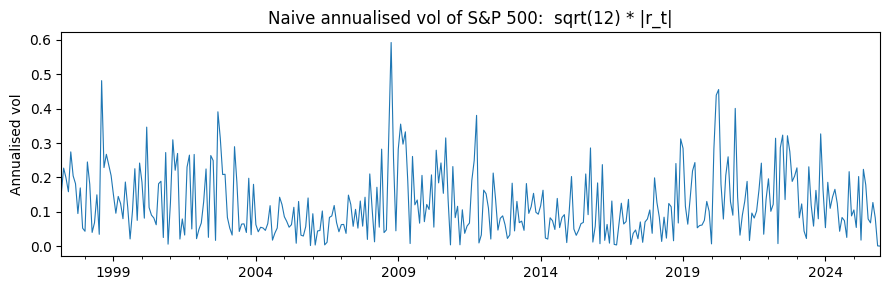

In [3]:
(np.sqrt(12) * df["S&P 500"].abs()).plot(figsize=(9, 3), lw=0.8)
plt.title("Naive annualised vol of S&P 500:  sqrt(12) * |r_t|")
plt.ylabel("Annualised vol")
plt.tight_layout()
plt.show()

## 2. Sample covariance and its correlation structure

Split the history into an estimation window (everything but the last 120 months) and a
*future* window (the last 120 months). We estimate covariance on the past and ask how well it
describes the future. `compute_covariance` returns an N x N `pd.DataFrame`; multiply by 12 to
annualise monthly covariance.

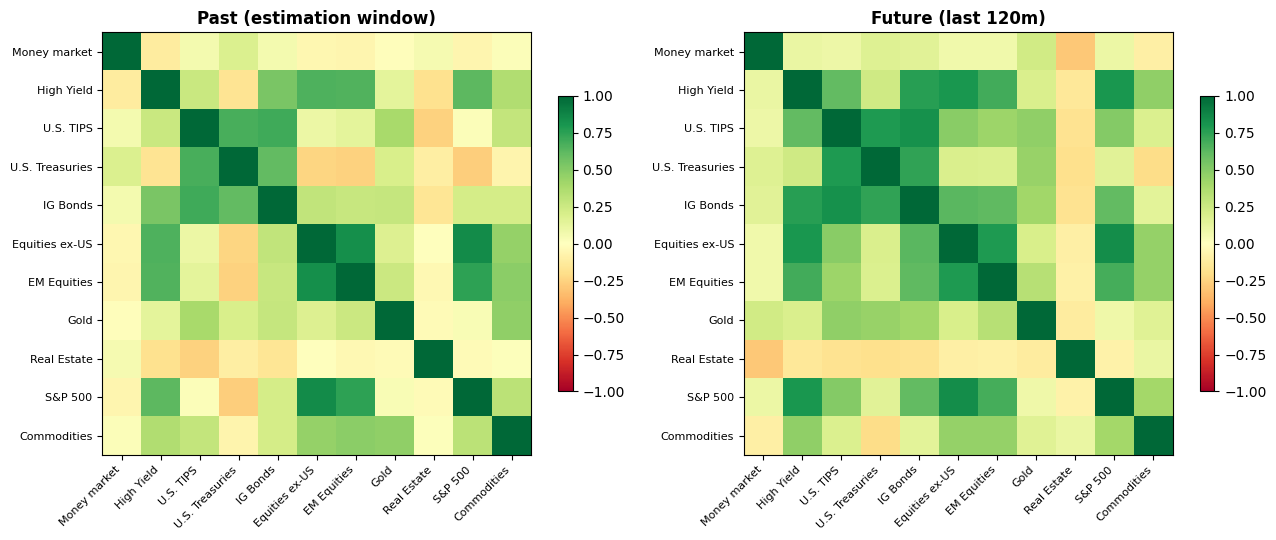

,Money market,High Yield,U.S. TIPS,U.S. Treasuries,IG Bonds,Equities ex-US,EM Equities,Gold,Real Estate,S&P 500,Commodities
Money market,1.0000,-0.1200,0.0600,0.1800,0.0600,-0.0500,-0.0600,-0.0100,0.0500,-0.0600,0.0200
High Yield,-0.1200,1.0000,0.2600,-0.1700,0.5400,0.6600,0.6500,0.1400,-0.1800,0.6200,0.3600
U.S. TIPS,0.0600,0.2600,1.0000,0.6800,0.7000,0.1000,0.1400,0.3900,-0.2500,0.0200,0.2900
U.S. Treasuries,0.1800,-0.1700,0.6800,1.0000,0.6100,-0.2400,-0.2500,0.2000,-0.1100,-0.2700,-0.0700
IG Bonds,0.0600,0.5400,0.7000,0.6100,1.0000,0.3000,0.2700,0.2800,-0.1600,0.2200,0.2200
Equities ex-US,-0.0500,0.6600,0.1000,-0.2400,0.3000,1.0000,0.8300,0.1700,0.0000,0.8500,0.4500
EM Equities,-0.0600,0.6500,0.1400,-0.2500,0.2700,0.8300,1.0000,0.2500,-0.0400,0.7500,0.4800
Gold,-0.0100,0.1400,0.3900,0.2000,0.2800,0.1700,0.2500,1.0000,-0.0300,0.0300,0.4700
Real Estate,0.0500,-0.1800,-0.2500,-0.1100,-0.1600,0.0000,-0.0400,-0.0300,1.0000,-0.0200,0.0100
S&P 500,-0.0600,0.6200,0.0200,-0.2700,0.2200,0.8500,0.7500,0.0300,-0.0200,1.0000,0.3100


In [4]:
past_df, future_df = df.iloc[:-120], df.iloc[-120:]

sample_cov = compute_covariance(past_df, method="sample") * 12
future_cov = compute_covariance(future_df, method="sample") * 12

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (corr, title) in zip(
    axes,
    [(cov_to_corr(sample_cov), "Past (estimation window)"),
     (cov_to_corr(future_cov), "Future (last 120m)")],
):
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=8)
    ax.set_title(title, fontweight="bold")
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

cov_to_corr(sample_cov).round(2)

## 3. Which estimator best predicts future variance?

We compare each estimator's predicted variances (the diagonal of the annualised covariance,
estimated on the *past* window) against the realised future variances. The metric is the mean
absolute error across assets. This is the framework version of the PyPortfolioOpt
`risk_matrix` comparison, using `risk_models.covariance`.

In [5]:
future_var = np.diag(future_cov)

METHODS: list[CovMethod] = [
    "sample", "ledoit_wolf_cc", "ledoit_wolf_sf", "ledoit_wolf_id", "ewma", "semicovariance",
]
LABELS = {
    "sample": "Sample", "ledoit_wolf_cc": "LW const-corr", "ledoit_wolf_sf": "LW single-factor",
    "ledoit_wolf_id": "LW identity", "ewma": "EWMA hl=36m", "semicovariance": "Semicovariance",
}

errors = {}
for m in METHODS:
    kw = {"halflife": 36} if m == "ewma" else {}
    S = compute_covariance(past_df, method=m, **kw) * 12
    errors[LABELS[m]] = float(np.mean(np.abs(np.diag(S) - future_var)))

errors

{'Sample': 0.0062132677803892365,
 'LW const-corr': 0.0062132677803892365,
 'LW single-factor': 0.006213267780389233,
 'LW identity': 0.006028699584520173,
 'EWMA hl=36m': 0.004872183242275865,
 'Semicovariance': 0.005276546377028979}

### Adding a factor model to the comparison

A linear factor model imposes structure: $\Sigma = B\,F\,B^\top + D$, where $B$ are the
$N\times K$ loadings, $F$ the $K\times K$ factor covariance, and $D$ the diagonal of specific
variances. We use four broad factors and static OLS betas via
`compute_rolling_asset_factor_cov`, then read the reconstructed asset covariance's diagonal as
the factor-model variance forecast.

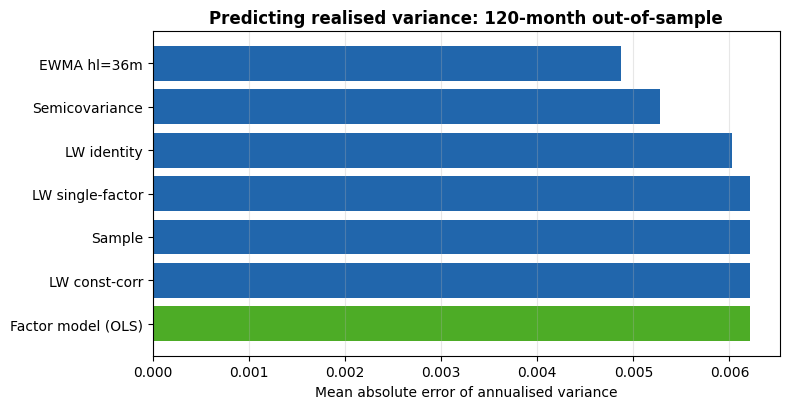

In [6]:
FACTORS = ["EQ_WL", "FI_GB_US", "GOLD", "CO"]
factor_ret = perf[[f"{f}-r" for f in FACTORS]].copy()
factor_ret.columns = pd.Index(FACTORS)
factor_ret = factor_ret.loc[df.index]

fcr_past = compute_rolling_asset_factor_cov(
    past_df, factor_ret.loc[past_df.index],
    dates=[past_df.index[-1]], beta_method="static",
    cov_method="ledoit_wolf_sf", annualize=True,
)
fcr = next(iter(fcr_past.values()))
fac_var = np.diag(fcr.asset_cov.loc[df.columns, df.columns].values)
errors["Factor model (OLS)"] = float(np.mean(np.abs(fac_var - future_var)))

# --- bar chart (sorted, factor model highlighted) ---
names = sorted(errors, key=errors.get)
vals = [errors[n] for n in names]
bar_colors = ["#4dac26" if "Factor" in n else "#2166ac" for n in names]

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(range(len(names)), vals, color=bar_colors)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel("Mean absolute error of annualised variance")
ax.set_title("Predicting realised variance: 120-month out-of-sample", fontweight="bold")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

The exponentially weighted estimator predicts future *variance* best — it down-weights stale
observations, so its diagonal tracks the changing volatility regime. Shrinkage targets and the
factor model leave the diagonal close to the sample variance: their value is in stabilising the
*correlation* structure and the matrix inverse, not in forecasting individual variances.

## 4. Rolling correlations

Correlations move through time. We track the equity/Treasury correlation under three estimators:
EWMA, a 60-month sample window, and a 60-month Ledoit-Wolf single-factor estimate. The
single-factor shrinkage produces a smoother, more stable path. (See
`risk_models/examples/covariance_example.py`.)

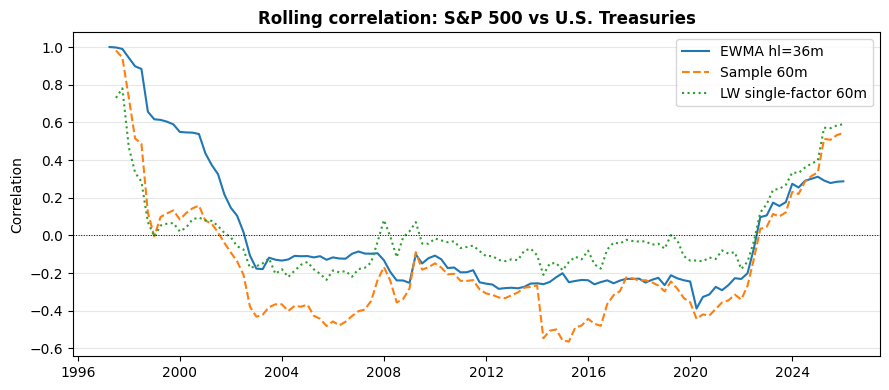

In [7]:
roll_ewma = compute_rolling_covariance(df, freq="QE", method="ewma", halflife=36)
roll_samp = compute_rolling_covariance(df, freq="QE", method="sample", lookback=60)
roll_lwsf = compute_rolling_covariance(df, freq="QE", method="ledoit_wolf_sf", lookback=60)

a, b = "S&P 500", "U.S. Treasuries"
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(*zip(*extract_rolling_corr(roll_ewma, a, b).items()), label="EWMA hl=36m", lw=1.5)
ax.plot(*zip(*extract_rolling_corr(roll_samp, a, b).items()), label="Sample 60m", lw=1.5, ls="--")
ax.plot(*zip(*extract_rolling_corr(roll_lwsf, a, b).items()), label="LW single-factor 60m", lw=1.5, ls=":")
ax.axhline(0, color="black", lw=0.7, ls=":")
ax.set_title(f"Rolling correlation: {a} vs {b}", fontweight="bold")
ax.set_ylabel("Correlation"); ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Correlation matrices across estimators

The same window, six estimators. Shrinkage pulls off-diagonal correlations toward the target
structure; the single-factor target ties cross-correlations to a common market factor.

C:\Users\jakub\gaa_students\risk_models\utils\__init__.py:55: RuntimeWarning: invalid value encountered in divide
  corr = cov.values / np.outer(std, std)


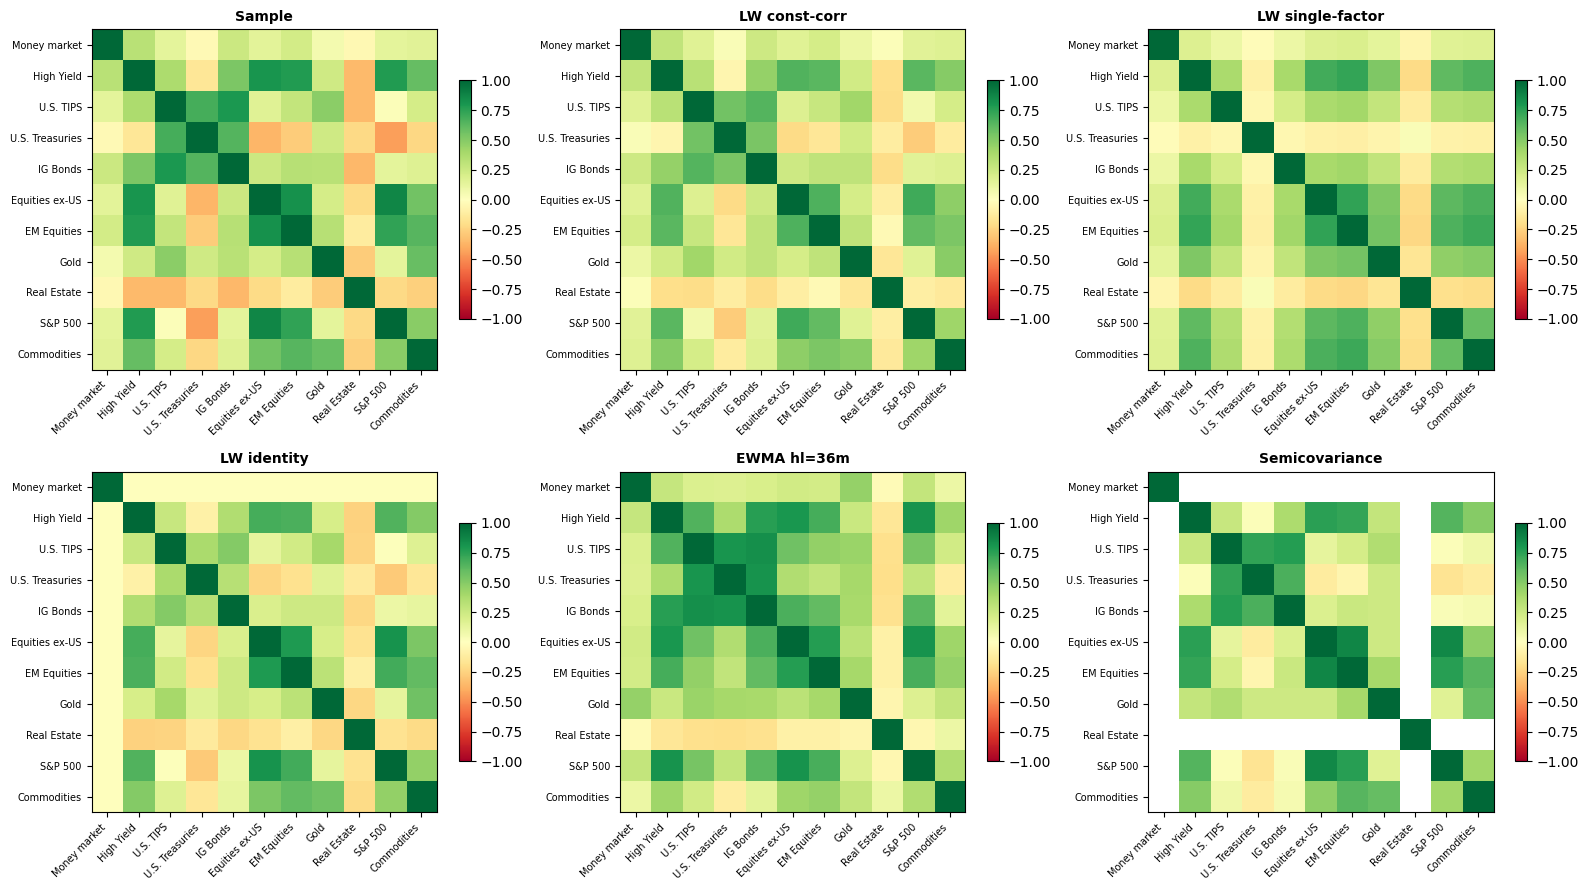

In [8]:
window = past_df.tail(60)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, m in zip(axes.flat, METHODS):
    data = df if m == "ewma" else window
    kw = {"halflife": 36} if m == "ewma" else {}
    corr = cov_to_corr(compute_covariance(data, method=m, **kw))
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=7)
    ax.set_title(LABELS[m], fontweight="bold", fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

## 6. Factor model: loadings and risk decomposition

The factor model summarises each asset's systematic exposure in $K=4$ betas instead of $N$
covariances. Below: the loading matrix $B$, then the split of each asset's variance into a
*systematic* part ($B F B^\top$ diagonal) and an *idiosyncratic* part ($D$).
(See `risk_models/examples/factor_covariance_example.py`.)

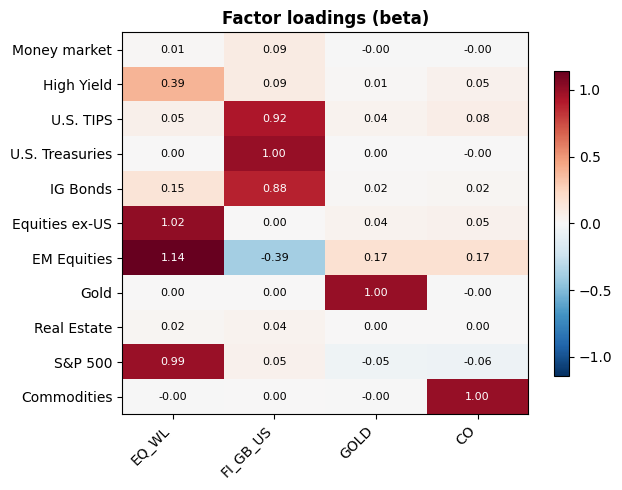

In [9]:
loadings = fcr.loadings
n, k = loadings.shape
vmax = float(np.nanmax(np.abs(loadings.values))) or 1.0

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(loadings.values, vmin=-vmax, vmax=vmax, cmap="RdBu_r", aspect="auto")
ax.set_xticks(range(k)); ax.set_xticklabels(loadings.columns, rotation=45, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(loadings.index)
ax.set_title("Factor loadings (beta)", fontweight="bold")
for i in range(n):
    for j in range(k):
        v = loadings.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="black" if abs(v) < 0.7 * vmax else "white")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

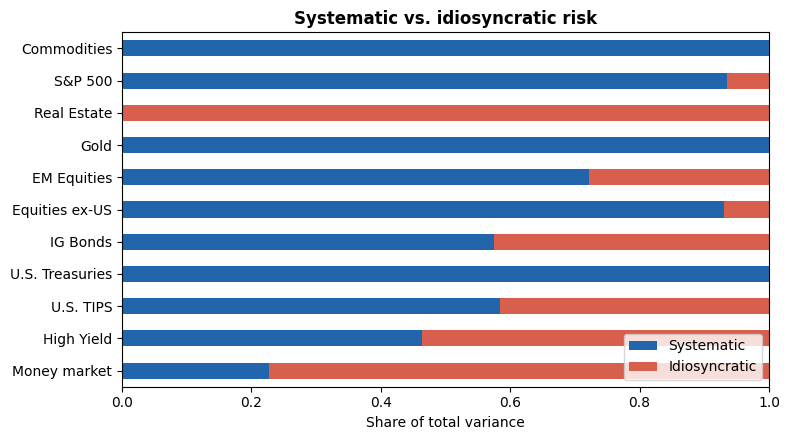

,Systematic,Idiosyncratic
Money market,0.2300,0.7700
High Yield,0.4600,0.5400
U.S. TIPS,0.5800,0.4200
U.S. Treasuries,1.0000,0.0000
IG Bonds,0.5800,0.4200
Equities ex-US,0.9300,0.0700
EM Equities,0.7200,0.2800
Gold,1.0000,0.0000
Real Estate,0.0000,1.0000
S&P 500,0.9400,0.0600


In [10]:
total_var = np.diag(fcr.asset_cov.values)
idio = fcr.idiosyncratic_var.values
syst = total_var - idio
share = pd.DataFrame(
    {"Systematic": syst / total_var, "Idiosyncratic": idio / total_var},
    index=fcr.asset_cov.index,
)
share.plot.barh(stacked=True, figsize=(8, 4.5), color=["#2166ac", "#d6604d"])
plt.xlabel("Share of total variance"); plt.title("Systematic vs. idiosyncratic risk", fontweight="bold")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()
share.round(2)

### Out-of-sample evaluation of the factor model

`evaluate_oos_covariance` rolls the factor model quarterly, compares each predicted covariance
against the realised covariance over the next 12 months, and reports the Frobenius loss and the
ratio of realised to predicted minimum-variance portfolio volatility (1.0 = perfectly
calibrated).

In [11]:
fac_roll = compute_rolling_asset_factor_cov(
    df, factor_ret, freq="QE", beta_method="static", lookback=120,
    cov_method="ledoit_wolf_sf", annualize=True,
)
oos = oos_results_to_df(evaluate_oos_covariance(df, fac_roll, horizon=12))
oos = oos[oos.index >= "2005-01-01"]
print(f"{len(oos)} quarterly snapshots, {oos.index[0].date()} -> {oos.index[-1].date()}")
oos[["frobenius_loss", "min_var_predicted_vol", "min_var_realised_vol", "min_var_vol_ratio"]].describe().round(4)

80 quarterly snapshots, 2005-03-31 -> 2024-12-31


,frobenius_loss,min_var_predicted_vol,min_var_realised_vol,min_var_vol_ratio
count,80.0000,80.0000,80.0000,80.0000
mean,0.0964,0.0057,0.0032,0.5941
std,0.0818,0.0020,0.0023,0.3981
min,0.0318,0.0025,0.0007,0.1129
25%,0.0543,0.0032,0.0019,0.3310
50%,0.0761,0.0066,0.0025,0.4503
75%,0.1054,0.0073,0.0034,0.7016
max,0.5147,0.0084,0.0124,1.9850


## Key takeaways

- The **sample covariance** is unbiased but noisy; shrinkage and factor structure trade a little
  bias for far lower estimation variance and a better-conditioned inverse.
- For predicting individual **variances**, **EWMA** wins — it adapts to the volatility regime.
- Shrinkage and the **factor model** earn their keep on the **correlation structure** and the
  matrix inverse, which is what portfolio optimisers actually consume.
- A factor model compresses $N(N+1)/2$ covariances into $N\times K$ loadings plus $K(K+1)/2$
  factor covariances — and lets us decompose risk into systematic and idiosyncratic parts.
- Always evaluate covariance models **out of sample** (Frobenius loss, min-variance vol ratio),
  not by in-sample fit.